In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()


df = pd.read_csv("sales_data.csv")

df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [5]:
print(df.isna())

       text   spam
0     False  False
1     False  False
2     False  False
3     False  False
4     False  False
...     ...    ...
5723  False  False
5724  False  False
5725  False  False
5726  False  False
5727  False  False

[5728 rows x 2 columns]


In [6]:
print(df.isna().sum())

text    0
spam    0
dtype: int64


In [7]:
df.duplicated()[df.duplicated()==True]

2155    True
2260    True
2412    True
2473    True
2763    True
3123    True
3152    True
3248    True
3249    True
3387    True
3573    True
3660    True
3690    True
3823    True
4203    True
4390    True
4394    True
4771    True
4785    True
5073    True
5180    True
5216    True
5316    True
5340    True
5473    True
5521    True
5542    True
5628    True
5632    True
5664    True
5674    True
5698    True
5716    True
dtype: bool

In [8]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (5728, 2) 

number of rows:  5728
number of columns:  2


In [26]:
df.dtypes

Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object

In [35]:
df.columns = df.columns.str.strip()   
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])
df['Sales_Amount'] = df['Sales_Amount'].replace(r'[\$,]', '', regex=True)
df['Sales_Amount'] = pd.to_numeric(df['Sales_Amount'])


In [10]:
df.describe(include='all')

,text,spam
count,5728,5728.000000
unique,5695,NaN
top,"Subject: re : contact info glenn , please , ...",NaN
freq,2,NaN
mean,NaN,0.238827
std,NaN,0.426404
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,0.000000


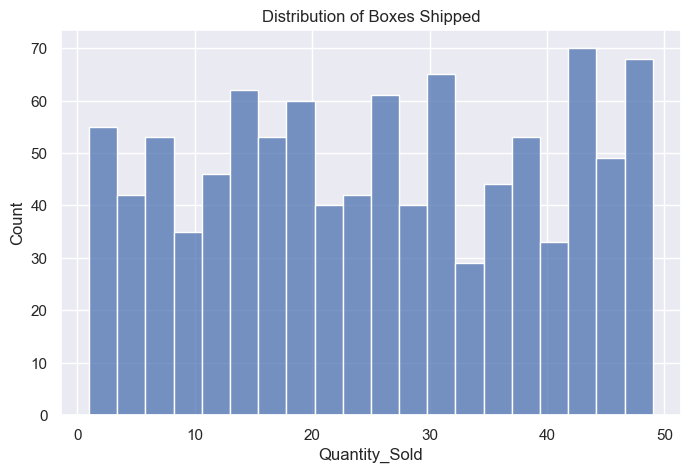

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity_Sold'], bins=20)
plt.title("Distribution of Boxes Shipped")
plt.show()

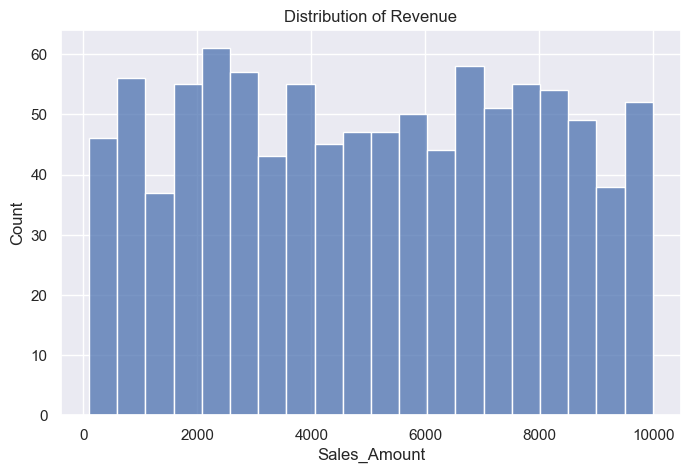

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales_Amount'], bins=20)
plt.title("Distribution of Revenue")
plt.show()

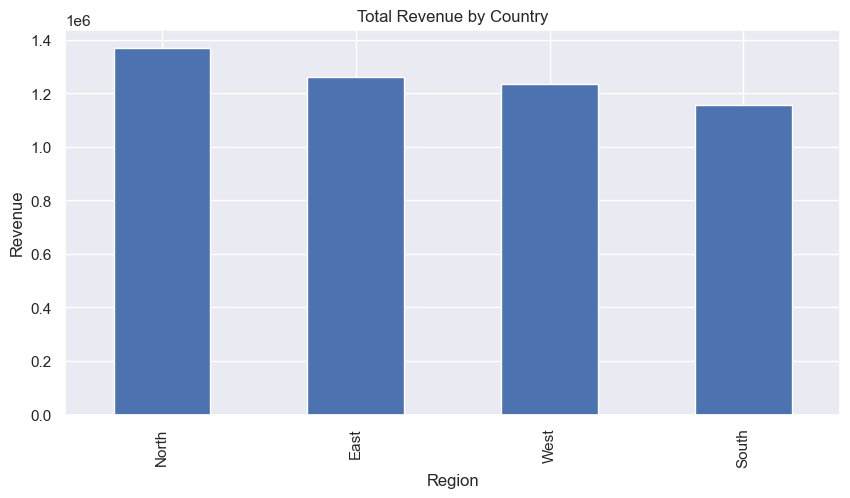

Region
North    1369612.51
East     1259792.93
West     1235608.93
South    1154250.86
Name: Sales_Amount, dtype: float64

In [37]:
country_revenue = df.groupby('Region')['Sales_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar')
plt.title("Total Revenue by Country")
plt.ylabel("Revenue")
plt.show()

country_revenue

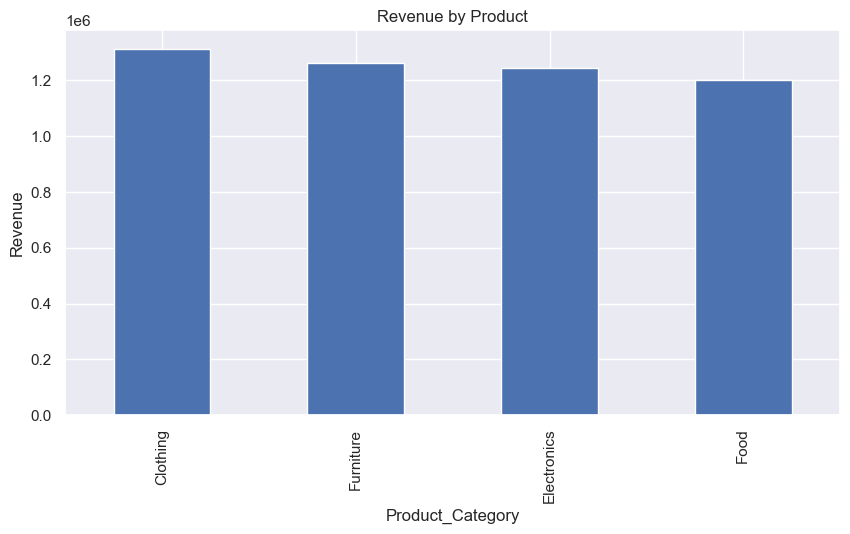

In [39]:
product_revenue = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

In [41]:
salesperson_revenue = df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False)

salesperson_revenue.head(10)

Sales_Rep
David      1141737.36
Bob        1080990.63
Eve         970183.99
Alice       965541.77
Charlie     860811.48
Name: Sales_Amount, dtype: float64

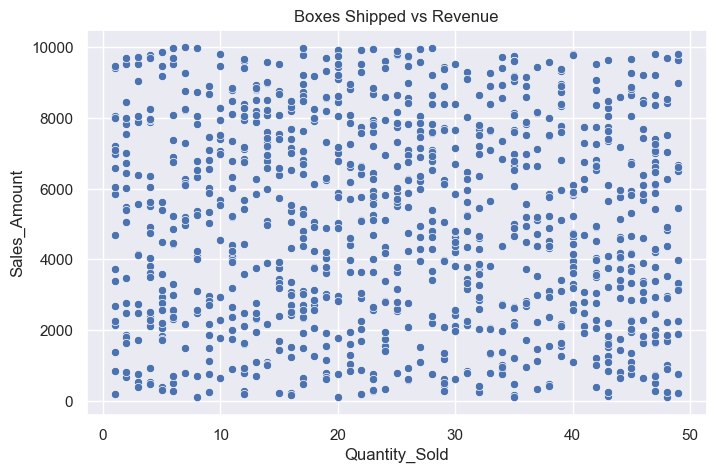

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Quantity_Sold', y='Sales_Amount', data=df)
plt.title("Boxes Shipped vs Revenue")
plt.show()

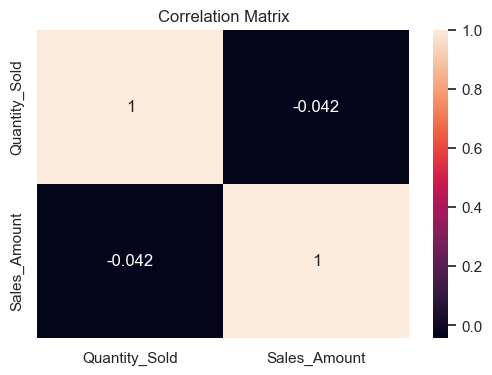

In [43]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Quantity_Sold', 'Sales_Amount']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

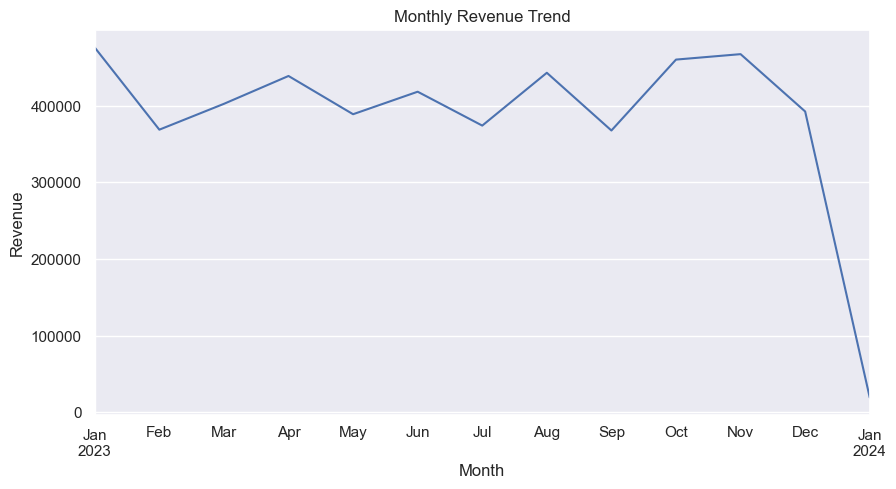

In [44]:
df['Month'] = df['Sale_Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Sales_Amount'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()